МОСКОВСКИЙ ГОСУДАРСТВЕННЫЙ ТЕХНИЧЕСКИЙ УНИВЕРСИТЕТ
им. Н.Э. Баумана

Факультет “Информатика и системы управления”
Кафедра “Системы обработки информации и управления”

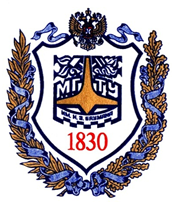

Дисциплина “Системное программирование”

Отчёт по лабораторной работе №3. Вариант №18
“Арифметические вычисления”

Выполнил:
Студент группы ИУ5-35Б
Сергучанов Т.Н.
Преподаватель:
Аксенова М.В
Артамонов Ю.Н.

Москва 2025


Задание:
1. На языке ассемблера реализовать программу, которая по введенному символу печатает его ASCII-код. Символ передавать в исполняемую программу как параметр командной строки.

2. Разработать программу на языке ассемблера, в которой в соответствии с вариантом выполнить расчет значения арифметического выражения и вывести результат на экран, операторы для арифметического выражения а, б, с передаются исполняемой программе как параметры командной строки.

3. На языке программирования С составить аналогичную п.2 программу, сверить полученные результаты.


Код программы пункта 1.

In [ ]:
format ELF64

public _start

section ".data" writeable
    result db ?, ?         '''выделяем два байта для результата вычеслений, но пока их ничем не заполняем'''

section ".text" executable
_start:
    cmp qword [rsp], 2     '''проверка на корректный ввод. Если пользователь не ввёл символ, то программа сразу же без ошибки завершается'''
    jl exit_program

    mov rbx, [rsp+16]      '''кладём в регистр rbx ASCII-код символа, введённого пользователем'''

    movzx eax, byte [rbx]  '''перекладываем в 32-разрядный регистр,
                              заполняя незаполненные ячейки нулями и делим на 10, благодаря чему десятки ASCII-кода будут сложены в eax, а единицы в edx'''
    mov edx, 0
    mov ecx, 10
    div ecx

    add eax, 48            '''прибавляем к единицам и десяткам ASCII-кода символа 48 (с тем же результатом можно добавить "0") чтобы превратить их в ASCII-код единиц и десятков'''
    add edx, 48

    mov [result], al       '''кладём полученные коды в ячейку для хранения результата'''
    mov [result+1], dl

    mov rax, 1             '''вывод результата в консоль'''
    mov rdi, 1
    mov rsi, result
    mov rdx, 2
    syscall

    exit_program:
        mov rax, 60        '''завершение программы'''
        mov rdi, 0
        syscall


Скриншоты работы программы пункта 1:
  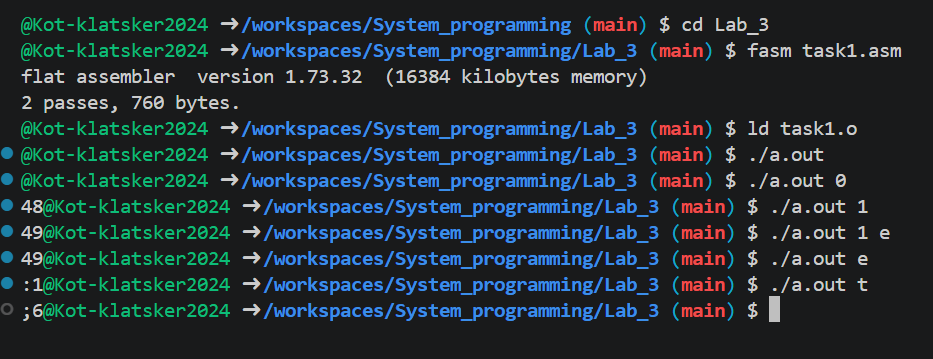

Код программы пункта 2.

In [ ]:
'''выражение моего варианта: (((a/b)+a)/c)'''

format ELF64

public _start

section ".data" writeable
    result db ?               '''выделяем один байт для результата вычеслений, но пока его ничем не заполняем'''

section ".text" executable
_start:
    cmp qword [rsp], 4        '''проверка на корректный ввод. Если пользователь не ввёл операторы для арифметического выражения, то программа сразу же без ошибки завершается'''
    jl exit_program

    mov r12, [rsp + 16]
    mov r13, [rsp + 24]       '''считываем операторы: r12 = a, r13 = b, r14 = c. Здесь они в виде ASCII-кодов'''
    mov r14, [rsp + 32]

    movzx eax, byte [r12]     '''перекладываем код а из r12 в eax, а оператор b в ecx, переводим их цифры, вычтя 48, и выполняем первое действие (a/b)'''
    sub eax, 48
    mov edx, 0
    movzx ecx, byte [r13]
    sub ecx, 48
    div ecx

    movzx ecx, byte [r12]     '''кладём в ecx код a, переводим в цифру и выполняем второе действие eax + с, так как в регистре eax находится результат деления первого дейтсвия'''
    sub ecx, 48
    add eax, ecx

    movzx ecx, byte [r14]     '''кладём в ecx код с, переводим в цифру и выполняем финальное действие eax/c, так как в регистре eax находится результат предыдущего действия'''
    sub ecx, 48
    mov edx, 0
    div ecx


    add eax, 48
    mov [result], al          '''переводим ответ выражения в ASCII-код и кладём в подготовленную ячейку для результата'''

    mov rax, 1
    mov rdi, 1
    mov rsi, result           '''вывод результата в консоль'''
    mov rdx, 1
    syscall

    exit_program:
        mov rax, 60           '''завершение программы'''
        mov rdi, 0
        syscall


Скриншот работы программы пункта 2:

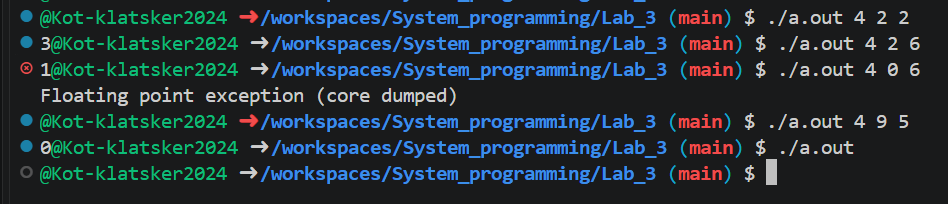


Примичание: ошибка Floating point exception (core dumped) возникает из-за попытки деления на ноль

Код программы пункта 3.

In [ ]:
#include <stdio.h>
#include <stdlib.h>                                             '''подключение библиотеки, где лежит функция atoi'''

int main(int argc, char *argv[]) {

    if (argc < 4) {
        printf("Использование: %s <a> <b> <c>\n", argv[0]);     '''проверка на корректный ввод.
                                                                Если пользователь ввёл неверно, программа выведет подсказку правильного заполнения и завершиться'''
        return 1;
    }

    int a = atoi(argv[1]);
    int b = atoi(argv[2]);
    int c = atoi(argv[3]);                                      '''перевод операторов выражения из строк в числа'''

    if (b == 0 || c == 0) {
        printf("Ошибка: Деление на ноль невозможно!\n");        '''проверка деления на ноль'''
        return 1;
    }

    int result = (((a / b) + a) / c);                           '''решение выражения и запись результата'''

    printf("Результат: %d\n", result);                          '''вывод результата в консоль и завершение программы'''

    return 0;
}


Скриншот работы программы пункта 3:
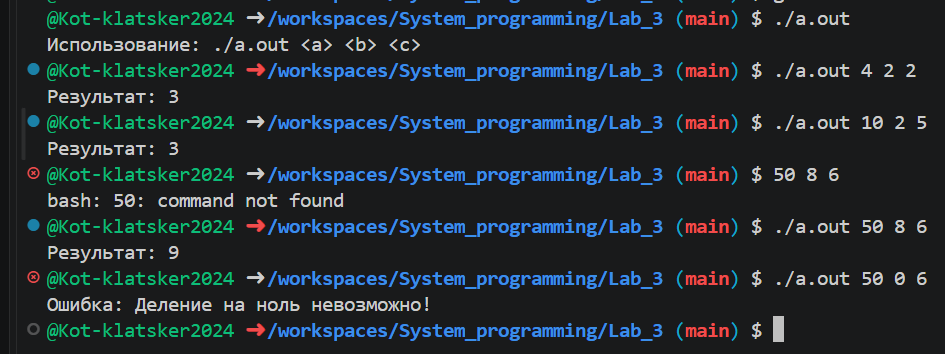